# Heart Disease Prediction Using Artificial Neural Network

## Problem Statement
Heart disease is a major health problem, and early prediction can help in identifying patients who may be at risk. The objective of this project is to develop an Artificial Neural Network (ANN) model that can predict the presence of heart disease using patient health-related attributes.


## Importing Required Libraries

The required Python libraries are imported for data analysis, visualization, numerical operations, and handling warnings.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

## Loading the Dataset

The Heart Disease dataset is loaded using the Pandas library. The `head()` function is used to display the first five rows of the dataset and verify that the data has been loaded correctly.

In [3]:
data = pd.read_csv("heart.csv")

data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


## Exploring the Dataset

The following functions are used to understand the basic structure and information of the Heart Disease dataset.

- `describe()` – Shows statistical summary of the numerical data.
- `shape` – Shows the number of rows and columns.
- `size` – Shows the total number of data values.
- `columns` – Displays the column names.
- `info()` – Shows column data types and missing values.

In [4]:
data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [5]:
data.shape

(303, 14)

In [6]:
data.size

4242

In [7]:
data.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


## Removing Unnecessary Columns

Unnecessary columns are removed from the dataset to keep only the relevant features required for analysis and model training.

In [9]:
data = data.drop(columns=['id', 'Unnamed: 32'], axis=1, errors='ignore')

data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [13]:
data["target"].value_counts()

1    165
0    138
Name: target, dtype: int64

## Visualizing Target Class Distribution

A count plot is used to visualize the number of records in each heart disease class.

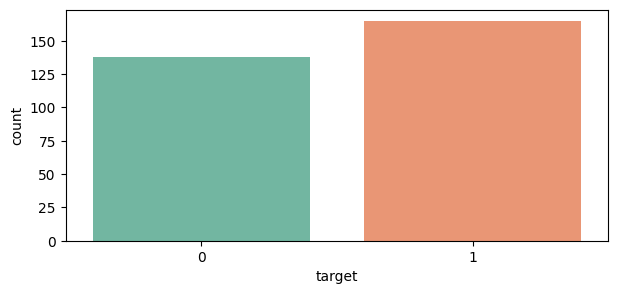

In [14]:
plt.figure(figsize=(7,3))

sns.countplot(x='target', data=data, palette="Set2")

plt.show()

## Checking Missing Values

The `isnull().sum()` function is used to check the number of missing values in each column of the dataset.

In [16]:
data.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

## Removing Duplicate Records

Duplicate records are removed from the dataset to avoid repeated data and improve the quality of the analysis.

In [17]:
data.drop_duplicates(inplace=True)
data.shape

(302, 14)

## Target Variable

The target variable is already represented using numerical values, so no additional encoding is required. The `target` column contains the class labels for heart disease prediction.

In [18]:
data["target"].value_counts()

data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


## Separating Input Features

The input features are separated from the target variable. The `target` column is removed from the dataset because it is the output variable we want the ANN model to predict.

In [19]:
X = data.drop("target", axis=1)

X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2


## Separating the Target Variable

The target variable is separated from the input features. The `target` column contains the class labels that the ANN model will learn to predict.

In [20]:
y = data["target"]

y.head()

0    1
1    1
2    1
3    1
4    1
Name: target, dtype: int64

## Splitting the Dataset

The dataset is divided into training and testing sets using `train_test_split()`.

- 80% of the data is used for training.
- 20% of the data is used for testing.
- `stratify=y` maintains the same target class distribution in both sets.

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((241, 13), (61, 13), (241,), (61,))

## Feature Scaling

Min-Max Scaling is used to transform the input features into a common range between 0 and 1. This helps the ANN model learn efficiently during training.

In [22]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train_fit = scaler.fit_transform(X_train)

X_test_fit = scaler.transform(X_test)

## Importing ANN Libraries

TensorFlow and Keras libraries are imported to build and train the Artificial Neural Network model.

- `Sequential` is used to create the neural network layer by layer.
- `Dense` is used to create fully connected neural network layers.
- `InputLayer` defines the input layer.
- `Dropout` helps reduce overfitting during model training.

In [23]:
import tensorflow as tf

import tensorflow.keras as keras

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Dense, InputLayer, Dropout

## Building the Artificial Neural Network

A Sequential ANN model is created with an input layer, two hidden layers, and an output layer. ReLU activation is used in the hidden layers, while sigmoid activation is used in the output layer for binary classification.

In [24]:
ann = Sequential()

ann.add(InputLayer(input_shape=(13,)))

ann.add(Dense(26, activation='relu'))

ann.add(Dense(15, activation='relu'))

ann.add(Dense(1, activation='sigmoid'))

ann.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 26)                364       
                                                                 
 dense_1 (Dense)             (None, 15)                405       
                                                                 
 dense_2 (Dense)             (None, 1)                 16        
                                                                 
Total params: 785
Trainable params: 785
Non-trainable params: 0
_________________________________________________________________


## Compiling the ANN Model

The ANN model is compiled by specifying the loss function, optimizer, and evaluation metric. Binary cross-entropy is used for binary classification, Adam is used to optimize the model, and accuracy is used to measure the prediction performance.

In [25]:
ann.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

## Training the ANN Model

The ANN model is trained using the training data for 100 epochs. The test data is used as validation data to monitor the model performance during training.

In [26]:
ann.fit(
    X_train_fit,
    y_train,
    epochs=100,
    validation_data=(X_test_fit, y_test)
)

Epoch 1/100
8/8 [==============================] - 1s 90ms/step - loss: 0.6808 - accuracy: 0.6141 - val_loss: 0.6638 - val_accuracy: 0.7705
Epoch 2/100
8/8 [==============================] - 0s 7ms/step - loss: 0.6644 - accuracy: 0.7220 - val_loss: 0.6496 - val_accuracy: 0.8525
Epoch 3/100
8/8 [==============================] - 0s 7ms/step - loss: 0.6501 - accuracy: 0.7759 - val_loss: 0.6365 - val_accuracy: 0.8525
Epoch 4/100
8/8 [==============================] - 0s 8ms/step - loss: 0.6367 - accuracy: 0.7842 - val_loss: 0.6227 - val_accuracy: 0.8689
Epoch 5/100
8/8 [==============================] - 0s 8ms/step - loss: 0.6231 - accuracy: 0.7842 - val_loss: 0.6081 - val_accuracy: 0.8525
Epoch 6/100
8/8 [==============================] - 0s 9ms/step - loss: 0.6095 - accuracy: 0.7925 - val_loss: 0.5927 - val_accuracy: 0.8525
Epoch 7/100
8/8 [==============================] - 0s 8ms/step - loss: 0.5939 - accuracy: 0.8008 - val_loss: 0.5766 - val_accuracy: 0.8525
Epoch 8/100
8/8 [=========

## Visualizing Model Loss

The training history is converted into a DataFrame and plotted to visualize the loss values during the training process.

<Axes: >

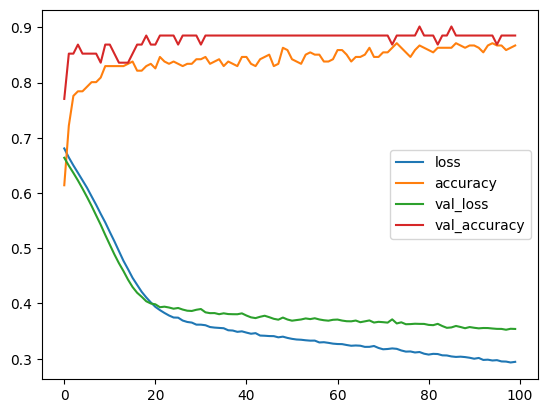

In [27]:
model_loss = pd.DataFrame(ann.history.history)

model_loss.plot()

## Early Stopping

Early Stopping is used to stop the training process when the validation loss stops improving. This helps prevent overfitting and avoids unnecessary training.

In [28]:
from tensorflow.keras.callbacks import EarlyStopping

es = EarlyStopping(
    monitor="val_loss",
    mode="min",
    verbose=1,
    patience=50
)

ann.fit(
    X_train_fit,
    y_train,
    epochs=100,
    validation_data=(X_test_fit, y_test),
    callbacks=[es]
)

Epoch 1/100
8/8 [==============================] - 0s 17ms/step - loss: 0.2918 - accuracy: 0.8714 - val_loss: 0.3517 - val_accuracy: 0.8852
Epoch 2/100
8/8 [==============================] - 0s 9ms/step - loss: 0.2909 - accuracy: 0.8631 - val_loss: 0.3506 - val_accuracy: 0.8852
Epoch 3/100
8/8 [==============================] - 0s 7ms/step - loss: 0.2905 - accuracy: 0.8672 - val_loss: 0.3531 - val_accuracy: 0.8852
Epoch 4/100
8/8 [==============================] - 0s 7ms/step - loss: 0.2916 - accuracy: 0.8631 - val_loss: 0.3525 - val_accuracy: 0.8852
Epoch 5/100
8/8 [==============================] - 0s 8ms/step - loss: 0.2934 - accuracy: 0.8714 - val_loss: 0.3607 - val_accuracy: 0.8525
Epoch 6/100
8/8 [==============================] - 0s 8ms/step - loss: 0.2878 - accuracy: 0.8880 - val_loss: 0.3519 - val_accuracy: 0.8852
Epoch 7/100
8/8 [==============================] - 0s 8ms/step - loss: 0.2935 - accuracy: 0.8548 - val_loss: 0.3502 - val_accuracy: 0.9016
Epoch 8/100
8/8 [=========

In [29]:
ann.save("heart-disease-ann.h5")

## Saving the Scaler

The trained scaler is saved using Python's pickle module. The saved scaler can be loaded later to apply the same feature scaling to new data before making predictions.

In [30]:
# Save the scaler parameters

import pickle

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

## Making Predictions on New Heart Disease Data

The trained ANN model and the saved scaler are loaded to make predictions on new patient data. The input features are arranged in the same order as the training data, scaled using the saved scaler, and then passed to the ANN model. The model predicts whether heart disease is present or absent.

In [31]:
import tensorflow as tf
import pandas as pd
import pickle
import warnings

warnings.filterwarnings("ignore")


# ==========================================
# 1. Load the trained model
# ==========================================

model = tf.keras.models.load_model("heart-disease-ann.h5")


# ==========================================
# 2. Load the fitted scaler
# ==========================================

with open("scaler.pkl", "rb") as f:
    scaler = pickle.load(f)


# ==========================================
# 3. Prepare input data
# ==========================================

input_data = {
    'age': [55],
    'sex': [1],
    'cp': [1],
    'trestbps': [140],
    'chol': [250],
    'fbs': [0],
    'restecg': [1],
    'thalach': [150],
    'exang': [0],
    'oldpeak': [1.0],
    'slope': [1],
    'ca': [0],
    'thal': [2]
}


# ==========================================
# 4. Convert input data to DataFrame
# ==========================================

input_df = pd.DataFrame(input_data)


# ==========================================
# 5. Check expected features
# ==========================================

expected_features = scaler.feature_names_in_

missing_features = set(expected_features) - set(input_df.columns)

extra_features = set(input_df.columns) - set(expected_features)


if missing_features:
    raise ValueError(
        f"Missing features in input data: {missing_features}"
    )

if extra_features:
    raise ValueError(
        f"Extra features in input data: {extra_features}"
    )


# ==========================================
# 6. Arrange columns in training order
# ==========================================

input_df = input_df[expected_features]


# ==========================================
# 7. Scale input data
# ==========================================

input_array = scaler.transform(input_df)


# ==========================================
# 8. Make prediction
# ==========================================

predictions = model.predict(input_array, verbose=0)


# ==========================================
# 9. Convert probability to class
# ==========================================

predicted_classes = (predictions > 0.5).astype("int32")


# ==========================================
# 10. Map class labels
# ==========================================

class_mapping = {
    0: "No Heart Disease",
    1: "Heart Disease"
}


predicted_class_names = [
    class_mapping[int(label[0])]
    for label in predicted_classes
]


# ==========================================
# 11. Display result
# ==========================================

print("\nPrediction Probability:", predictions[0][0])
print("Predicted Class:", predicted_classes[0][0])
print("Predicted Class Name:", predicted_class_names[0])


Prediction Probability: 0.7464708
Predicted Class: 1
Predicted Class Name: Heart Disease
